In [ ]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          09-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import ensemble, tree
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import plot_tree

# De data waarop getraind wordt.
data = pd.read_csv("churndata.csv")


In [ ]:
#Parameters voor de gradient boosting algoritme.
params = {
    "n_estimators": 2000,
    "max_depth": 14,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}


In [ ]:
# De churn wordt uit de traindata gelaten.
train = data.drop(columns = ['Churn'])
Y = data['Churn']

# Het splitten van de data wordt hier gedaan.
X_train, X_test, y_train, y_test = train_test_split(train, Y, test_size = 0.2, random_state = 1987)


In [ ]:
# Hier wordt het fitten gedaan op de data.
boosting = ensemble.GradientBoostingRegressor(**params)
boosted = boosting.fit(X_train, y_train)
print(boosted.estimators_)


In [ ]:
# Hier wordt het voorspellen op de data gedaan.
pred = boosting.predict(X_test)
mse = mean_squared_error(y_test, pred)
res = np.where((pred[:] > 0.6), 1, 0)
acc = accuracy_score(y_test, res)


In [ ]:
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))
print("Gradient Boosting Classifier accuracy is : {:.2f}".format(acc))


The mean squared error (MSE) on test set: 0.0533
Gradient Boosting Classifier accuracy is : 0.94


In [ ]:
predict_data = pd.read_csv("churndata_deployment.csv")
new = boosting.predict(predict_data)
print(new)


[ 9.02703031e-05  1.13423439e+00 -3.06693298e-06  1.06910916e+00
 -4.12389289e-04 -2.41720085e-03  2.16661742e-03  2.21941394e-01
  9.99669936e-05 -6.69043207e-04  8.07186177e-01  7.80070663e-06
 -2.35311415e-07  9.99970382e-01  2.18662904e-06  2.04174928e-06
  4.96502066e-07  9.89179443e-01  6.37922772e-07  3.44098978e-06
  3.26164429e-04  3.18618149e-05  1.00001353e+00  3.04889811e-03
  1.00020667e+00 -2.91008573e-03  9.43615217e-04  2.07867175e-05
 -7.06040842e-05  2.59246786e-03  6.00000227e-01  6.23901376e-05
 -1.69216490e-03  6.24999604e-01 -5.03731986e-07 -4.49304155e-05
 -3.76999107e-06  5.74474025e-06  1.69857303e-03  9.99786297e-01
  8.16966260e-05  1.81390666e-05 -6.29554730e-07 -9.92079478e-07
 -1.10405742e-06  3.53099893e-01 -3.10152872e-03  9.99934727e-01
  1.03372214e-05  1.10988276e-06  9.98849463e-01  8.44043933e-07
 -9.18510428e-08 -1.61153323e-05  9.94464678e-01  4.39980091e-03
 -1.25408775e-03  4.11902928e-06  5.09604671e-05  7.32742302e-02
  1.23790605e-05  9.99994

c:\Users\jeffr\anaconda3\envs\BP3.4\Lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


AttributeError: 'GradientBoostingRegressor' object has no attribute 'get_dump'

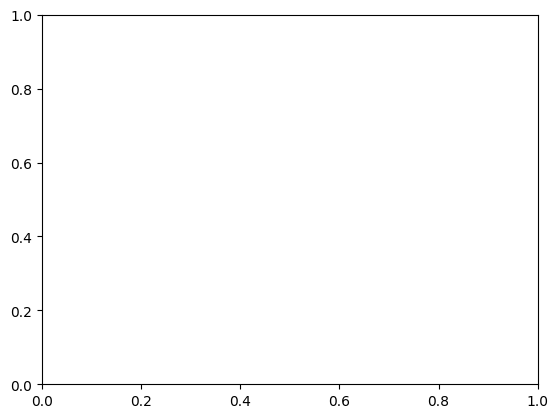

In [ ]:
plot_tree(boosting, num_trees = 0)
plt.show()
